# Problema de Distribuição de Água

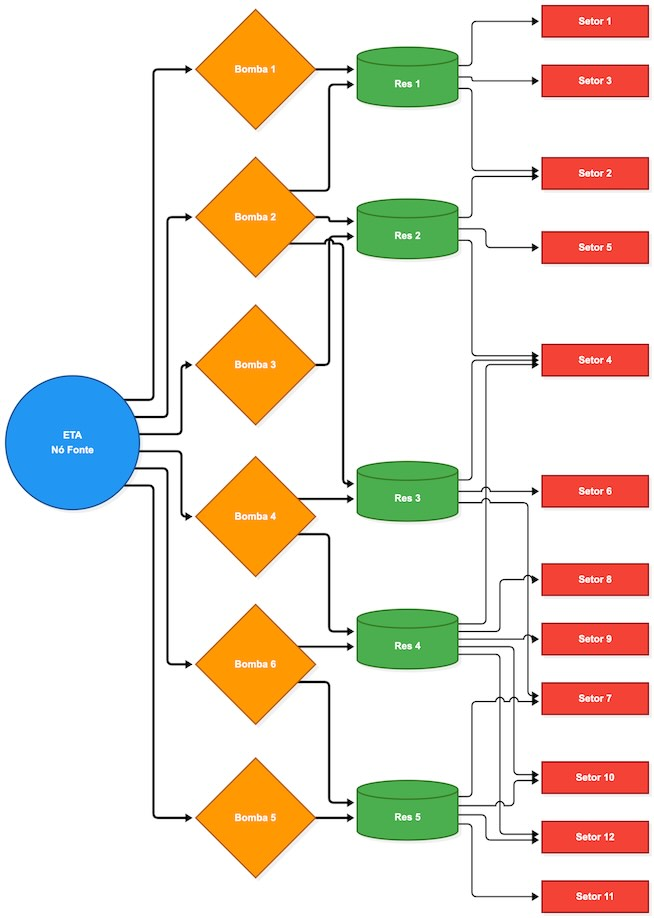

## Tarifas horossazonais reais (ANEEL — estado de São Paulo)

Em vez de tarifas hipotéticas (R$ 0,60 / R$ 2,80), o parâmetro $C_t$ passa a usar as **tarifas homologadas pela ANEEL** para distribuidoras paulistas (análise em `analise_horossazonal_aneel.ipynb`).

**Como o R$/kWh é obtido:** `(TUSD em R$/MWh + TE em R$/MWh) ÷ 1.000`, sem tributos (ICMS, PIS/COFINS) e sem bandeiras.

**Escolha do cenário** (edite os 3 parâmetros abaixo):
- `DISTRIBUIDORA`: concessionária que atende a ETA (ex.: `ELETROPAULO`, `CPFL-PAULISTA`, `CPFL-PIRATINING`, `CPFL Santa Cruz`, `EDP SP`, `ELEKTRO`);
- `MODALIDADE`: `Verde` ou `Azul`;
- `SUBGRUPO`: `A4` (2,3 a 25 kV) é o mais comum para estações de bombeamento.

> **Atenção:** na modalidade **Verde** a TUSD de ponta (R$/MWh) já embute a cobrança de demanda de ponta, por isso o preço da ponta é muito alto (3x a 5x). Na **Azul** a demanda é cobrada à parte (R$/kW), **fora** da função objetivo deste modelo, então o custo de energia da Azul não inclui a demanda contratada. O CSV da ANEEL não define os horários de ponta: eles dependem da distribuidora (ver `HORAS_PONTA` na célula seguinte).

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

# ===== Parâmetros de cenário tarifário =====
NOME_ARQUIVO_ANEEL = "tarifas-homologadas-distribuidoras-energia-eletrica.csv"
ARQUIVO_ANEEL = next(
    (
        pasta / "dados" / NOME_ARQUIVO_ANEEL
        for pasta in (Path.cwd(), *Path.cwd().parents)
        if (pasta / "dados" / NOME_ARQUIVO_ANEEL).is_file()
    ),
    None,
)
if ARQUIVO_ANEEL is None:
    raise FileNotFoundError(
        f"Arquivo '{NOME_ARQUIVO_ANEEL}' não encontrado na pasta 'dados' "
        f"da pasta atual ou de suas pastas ancestrais. Diretório atual: {Path.cwd()}"
    )
DISTRIBUIDORA = "ELETROPAULO"   # Enel SP (ex-Eletropaulo)
MODALIDADE    = "Verde"         # "Verde" ou "Azul"
SUBGRUPO      = "A4"
DATA_REFERENCIA = pd.Timestamp("2026-10-06")   # use pd.Timestamp.today() para a data atual

# Distribuidoras de SP com tarifa vigente (o CSV não possui coluna de UF)
DISTRIBUIDORAS_SP = ["ELETROPAULO", "EDP SP", "CPFL-PAULISTA", "CPFL-PIRATINING", "CPFL Santa Cruz", "ELEKTRO"]

def carregar_aneel(caminho=ARQUIVO_ANEEL):
    df = pd.read_csv(caminho, sep=";", dtype=str)
    for c in ["DatInicioVigencia", "DatFimVigencia"]:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    for c in ["VlrTUSD", "VlrTE"]:
        df[c] = pd.to_numeric(df[c].str.replace(".", "", regex=False).str.replace(",", ".", regex=False), errors="coerce")
    return df

def tarifa_kwh(df, distribuidora, modalidade="Verde", subgrupo="A4", data_ref=DATA_REFERENCIA):
    """Tarifa de energia (TUSD + TE, R$/kWh) em ponta e fora ponta, vigente em data_ref."""
    f = df[(df["SigAgente"] == distribuidora)
           & (df["DatInicioVigencia"] <= data_ref) & (df["DatFimVigencia"] >= data_ref)
           & (df["DscBaseTarifaria"] == "Tarifa de Aplicação")
           & (df["DscModalidadeTarifaria"] == modalidade) & (df["DscSubGrupo"] == subgrupo)
           & (df["DscClasse"] == "Não se aplica") & (df["DscSubClasse"] == "Não se aplica")
           & (df["DscDetalhe"] == "Não se aplica") & (df["SigAgenteAcessante"] == "Não se aplica")
           & (df["DscUnidadeTerciaria"] == "MWh") & (df["NomPostoTarifario"].isin(["Ponta", "Fora ponta"]))]
    if f.empty:
        raise ValueError(f"Sem tarifa para {distribuidora} / {modalidade} / {subgrupo} em {data_ref.date()}")
    v = (f["VlrTUSD"].fillna(0) + f["VlrTE"].fillna(0)) / 1000
    por_posto = v.groupby(f["NomPostoTarifario"]).first()
    return {"fora_ponta": float(por_posto["Fora ponta"]), "ponta": float(por_posto["Ponta"]),
            "vigencia": (f["DatInicioVigencia"].iloc[0].date(), f["DatFimVigencia"].iloc[0].date())}

def tarifa_demanda_kw(df, distribuidora, modalidade="Verde", subgrupo="A4", data_ref=DATA_REFERENCIA):
    """Tarifa de demanda (TUSD em R$/kW), vigente em data_ref. Azul: ponta e fora ponta; Verde: única."""
    f = df[(df["SigAgente"] == distribuidora)
           & (df["DatInicioVigencia"] <= data_ref) & (df["DatFimVigencia"] >= data_ref)
           & (df["DscBaseTarifaria"] == "Tarifa de Aplicação")
           & (df["DscModalidadeTarifaria"] == modalidade) & (df["DscSubGrupo"] == subgrupo)
           & (df["DscClasse"] == "Não se aplica") & (df["DscSubClasse"] == "Não se aplica")
           & (df["DscDetalhe"] == "Não se aplica") & (df["SigAgenteAcessante"] == "Não se aplica")
           & (df["DscUnidadeTerciaria"] == "kW")]
    por_posto = f.groupby("NomPostoTarifario")["VlrTUSD"].first()
    if modalidade == "Azul":
        return {"ponta": float(por_posto["Ponta"]), "fora_ponta": float(por_posto["Fora ponta"])}
    return {"unica": float(por_posto["Não se aplica"])}

aneel = carregar_aneel()
t = tarifa_kwh(aneel, DISTRIBUIDORA, MODALIDADE, SUBGRUPO)
tarifa_fora_ponta, tarifa_ponta = t["fora_ponta"], t["ponta"]

print(f"{DISTRIBUIDORA} | {MODALIDADE} | {SUBGRUPO} | vigência {t['vigencia'][0]} a {t['vigencia'][1]}")
print(f"  Fora ponta: R$ {tarifa_fora_ponta:.4f}/kWh")
print(f"  Ponta:      R$ {tarifa_ponta:.4f}/kWh  ({tarifa_ponta / tarifa_fora_ponta:.2f}x o fora ponta)")

ELETROPAULO | Verde | A4 | vigência 2026-07-04 a 2027-07-03
  Fora ponta: R$ 0.4525/kWh
  Ponta:      R$ 1.4048/kWh  (3.10x o fora ponta)


In [2]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Conjuntos de Índices
T = 24
horas = range(T)
bombas = range(1, 7)
reservatorios = range(1, 6)
setores = range(1, 13)

# 2. Topologia do Sistema (Arcos permitidos conforme o diagrama)
# Arcos (Bomba -> Reservatório)
arcos_PR = [
    (1,1),
    (2,1), (2,2), (2,3),
    (3,2),
    (4,3), (4,4),
    (5,5),
    (6,4), (6,5)
]

# Arcos (Reservatório -> Setor de Consumo)
arcos_RS = [
    (1,1), (1,2), (1,3),
    (2,2), (2,4), (2,5),
    (3,4), (3,6), (3,7),
    (4,4), (4,8), (4,9), (4,10), (4,12),
    (5,7), (5,10), (5,11), (5,12)
]

# 3. Parâmetros Econômicos (Tarifa Horossazonal - R$/kWh)
# As tarifas vêm do dataset da ANEEL (estado de SP), carregado na célula "Tarifas ANEEL" acima.
# Horário de ponta (17h, 18h, 19h) -> tarifa_ponta | demais horas -> tarifa_fora_ponta
HORAS_PONTA = (17, 18, 19)
C = {t: tarifa_ponta if t in HORAS_PONTA else tarifa_fora_ponta for t in horas}
# Valores anteriores (hipotéticos): fora de ponta R$ 0.60 | ponta R$ 2.80

# 4. Parâmetros das Bombas: {Bomba: (Potência kW, Q_min m3/h, Q_max m3/h)}
param_bombas = {
    1: (60,   0, 150),
    2: (120,  0, 280),
    3: (70,   0, 150),
    4: (80,   0, 180),
    5: (50,   0, 120),
    6: (70,   0, 150)
}
Q_ETA_max = 600 # Limite físico da ETA

# 5. Parâmetros dos Reservatórios: {Res: (V_min, V_max, V_inicial)}
# Volume inicial (V_inicial) 30% da capacidade.
# No verão, a concessionária precisa passar a madrugada enchendo tudo para aguentar o dia.
param_res = {
    1: (135,  900, 270),
    2: ( 90,  600, 180),
    3: ( 90,  600, 180),
    4: ( 90,  600, 180),
    5: ( 45,  300, 90)
}

# 6. Demanda dos Setores (m3/h)
base_demanda = {
    1: 20,  2: 30,  3: 25,  4: 40,
    5: 25,  6: 20,  7: 35,  8: 30,
    9: 20, 10: 45, 11: 25, 12: 18
}
# Soma das bases = 333 m3/h

# CURVA HORÁRIA - CENÁRIO DE VERÃO (~90% Consumo)
# Média da demanda ~460 m3/h (beirando o limite da ETA de 600)
# Picos chegam a bater 3.4x a base (1132 m3/h)
# Média do dia alta, mas com alívio real na madrugada para permitir recarga
curva_verao = [
    0.8, 0.5, 0.3, 0.4, 0.6, 1.0,   # 00h às 05h: Queda brusca do consumo na madrugada
    1.8, 2.0, 1.9, 1.7, 1.5, 1.5,   # 06h às 11h: Pico pesado da manhã
    1.4, 1.5, 1.6, 1.7, 1.8, 2.9,   # 12h às 17h: Consumo alto e contínuo
    3.4, 3.0, 2.6, 2.0, 1.5, 1.0    # 18h às 23h: Pico máximo (chegada da praia + banhos)
]

D = {}
for d in setores:
    for t in horas:
        D[d, t] = round(base_demanda[d] * curva_verao[t], 2)



In [3]:
# Criação do modelo
m = gp.Model("Agendamento_Bombas_MILP")
m.setParam('TimeLimit', 60) # Trava de segurança de 1 minuto
m.setParam('MIPGap', 0.01)  # Aceita a solução se o erro for menor que 1%


# 7. Variáveis de Decisão
# Variável Binária: x_{p,t}
x = m.addVars(bombas, horas, vtype=GRB.BINARY, name="x")

# Vazão total da bomba p no tempo t: q_{p,t}
q = m.addVars(bombas, horas, vtype=GRB.CONTINUOUS, name="q")

# Vazões nos arcos: f_{pr, t} e f_{rs, t}
f_pr = m.addVars(arcos_PR, horas, vtype=GRB.CONTINUOUS, name="f_pr")
f_rs = m.addVars(arcos_RS, horas, vtype=GRB.CONTINUOUS, name="f_rs")

# Volume no reservatório r ao final do tempo t: V_{r,t}
V = m.addVars(reservatorios, horas, vtype=GRB.CONTINUOUS, name="V")

# 8. Função Objetivo (Minimizar custo de energia)
m.setObjective(
    gp.quicksum(C[t] * param_bombas[p][0] * x[p,t] for p in bombas for t in horas),
    GRB.MINIMIZE
)

# 9. Restrições

# Eq 6: Regras lógicas das bombas (Big-M) e definição da vazão total
for p in bombas:
    Q_min, Q_max = param_bombas[p][1], param_bombas[p][2]
    for t in horas:
        m.addConstr(q[p,t] >= Q_min * x[p,t], name=f"Bomba_Min_{p}_{t}")
        m.addConstr(q[p,t] <= Q_max * x[p,t], name=f"Bomba_Max_{p}_{t}")

        # A vazão total da bomba p tem que ser igual à soma do que vai para os reservatórios conectados
        arcos_saida = [arco for arco in arcos_PR if arco[0] == p]
        m.addConstr(q[p,t] == gp.quicksum(f_pr[p,r,t] for (p,r) in arcos_saida), name=f"Fluxo_Bomba_{p}_{t}")

# Eq 7: Capacidade máxima da ETA
for t in horas:
    m.addConstr(gp.quicksum(q[p,t] for p in bombas) <= Q_ETA_max, name=f"Capacidade_ETA_{t}")

# Eq 5: Atendimento da demanda (Setores)
for d in setores:
    for t in horas:
        arcos_chegada = [arco for arco in arcos_RS if arco[1] == d]
        m.addConstr(gp.quicksum(f_rs[r,d,t] for (r,d) in arcos_chegada) == D[d,t], name=f"Demanda_{d}_{t}")

# Eq 2 e 3: Balanço hídrico e Limites dos Reservatórios
for r in reservatorios:
    V_min, V_max, V_inicial = param_res[r]
    for t in horas:
        # Vazão chegando no reservatório r
        arcos_in = [arco for arco in arcos_PR if arco[1] == r]
        vazao_in = gp.quicksum(f_pr[p,r,t] for (p,r) in arcos_in)

        # Vazão saindo do reservatório r
        arcos_out = [arco for arco in arcos_RS if arco[0] == r]
        vazao_out = gp.quicksum(f_rs[r,s,t] for (r,s) in arcos_out)

        # Delta t = 1 hora, logo volume = vazao * 1
        if t == 0:
            m.addConstr(V[r,t] == V_inicial + vazao_in - vazao_out, name=f"Balanco_{r}_{t}")
        else:
            m.addConstr(V[r,t] == V[r,t-1] + vazao_in - vazao_out, name=f"Balanco_{r}_{t}")

        # Eq 3: Limites de armazenamento
        m.addConstr(V[r,t] >= V_min, name=f"Vmin_{r}_{t}")
        m.addConstr(V[r,t] <= V_max, name=f"Vmax_{r}_{t}")

    # Eq 4: Recuperação de nível diário
    m.addConstr(V[r, 23] >= V_inicial, name=f"Recuperacao_{r}")



Restricted license - for non-production use only - expires 2027-11-29


Set parameter TimeLimit to value 60


Set parameter MIPGap to value 0.01


In [4]:
# 10. Otimização
m.optimize()

# Verificação do status
if m.status == GRB.OPTIMAL:
    print(f"\nSolução ótima encontrada!")
    print(f"Custo total de energia: R$ {m.objVal:.2f}")
else:
    print("\nModelo inviável ou sem solução ótima.")


Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.4 LTS")


CPU model: Intel(R) Xeon(R) Processor @ 2.10GHz, instruction set [SSE2|AVX|AVX2|AVX512]


Thread count: 1 physical cores, 1 logical processors, using up to 1 threads


Non-default parameters:


TimeLimit  60


...

Thread count was 1 (of 1 available processors)


Solution count 10: 2883.73 2888.26 2897.31 ... 2991.12


Optimal solution found (tolerance 1.00e-02)


Best objective 2.883730300000e+03, best bound 2.855731675745e+03, gap 0.9709%



Solução ótima encontrada!
Custo total de energia: R$ 2883.73


# GRÁFICOS E RESULTADOS

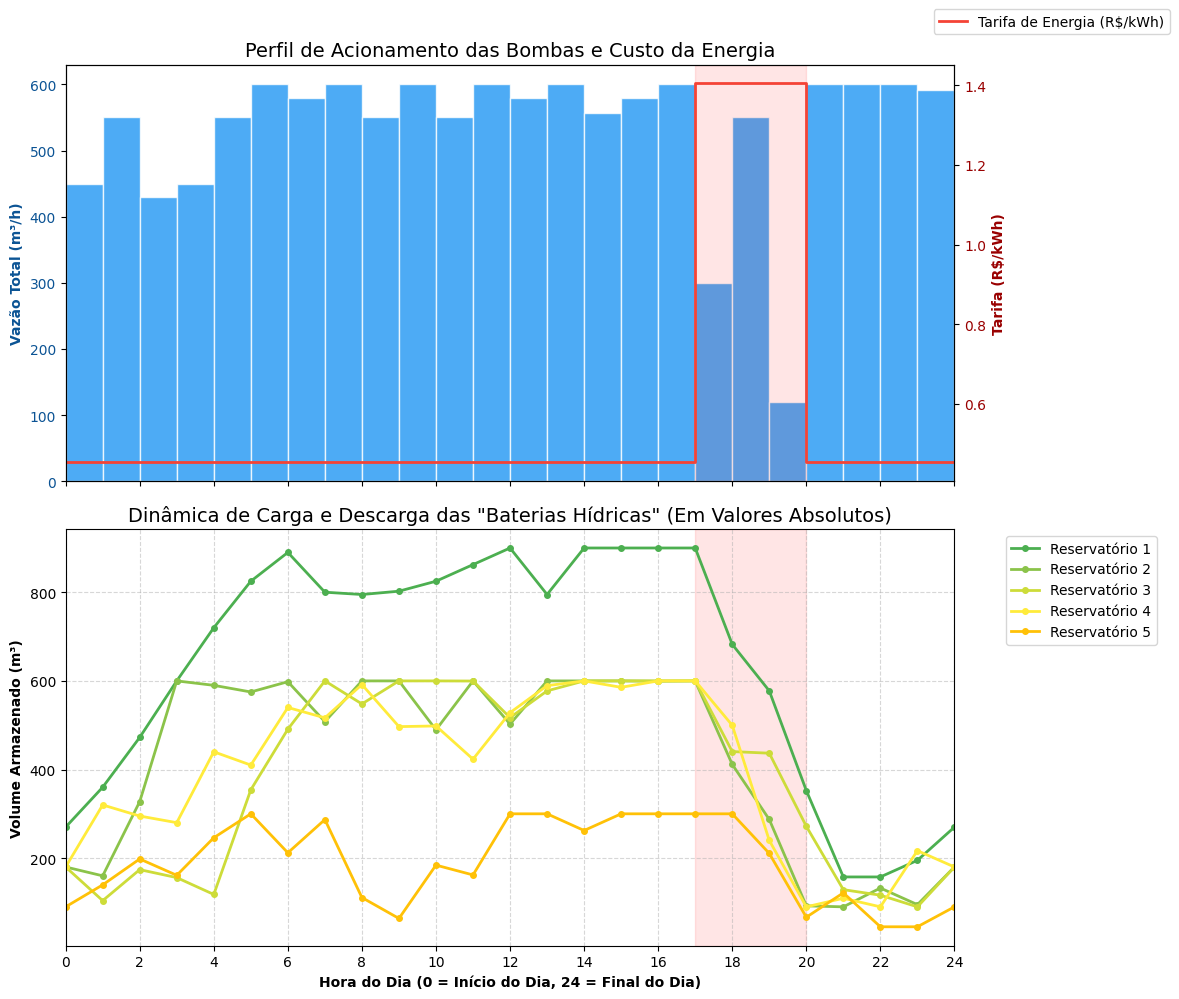

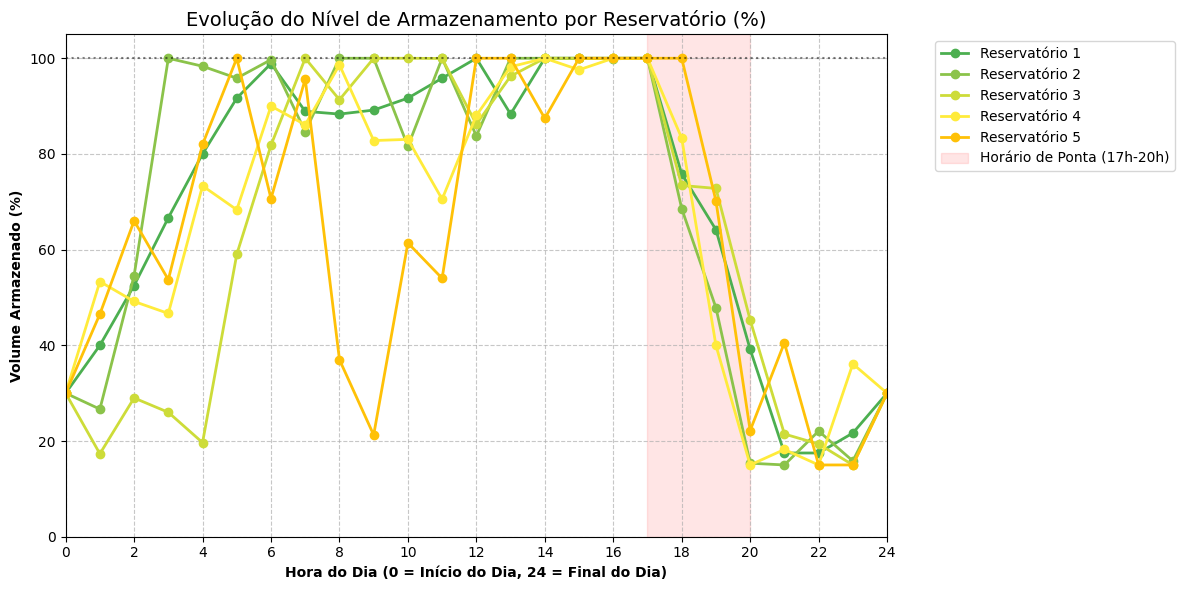

In [5]:
# Célula 3: Extração de Resultados e Visualização (Matplotlib)
if m.status == GRB.OPTIMAL or (m.status == GRB.TIME_LIMIT and m.SolCount > 0):
    import matplotlib.pyplot as plt

    # 1. Preparação dos dados
    # Eixo X da linha do tempo contínua com 25 marcos (0 a 24)
    horas_plot = list(range(25))

    # Vazão total bombeada (24 blocos de 1 hora)
    vazao_total = [sum(q[p, t].X for p in bombas) for t in horas]

    # Preço da energia (Adicionado o último valor repetido apenas para o gráfico desenhar o degrau até o final da hora 24)
    preco_energia = [C[t] for t in horas]
    preco_energia.append(preco_energia[-1])

    # 2. Configuração da Figura
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # --- GRÁFICO 1: Operação das Bombas vs Tarifa ---
    # align='edge' e width=1 faz com que a barra da hora t ocupe exatamente o espaço de t até t+1
    ax1.bar(horas, vazao_total, width=1, align='edge', color='#2196F3', alpha=0.8, edgecolor='white', label='Volume Bombeado (m³/h)')
    ax1.set_ylabel('Vazão Total (m³/h)', color='#0b5394', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#0b5394')
    ax1.set_title('Perfil de Acionamento das Bombas e Custo da Energia', fontsize=14)

    # Eixo secundário: Gráfico em degrau (step) para mostrar a constância da tarifa durante o bloco de tempo
    ax1_twin = ax1.twinx()
    ax1_twin.step(horas_plot, preco_energia, where='post', color='#f44336', linewidth=2, label='Tarifa de Energia (R$/kWh)')
    ax1_twin.set_ylabel('Tarifa (R$/kWh)', color='#990000', fontweight='bold')
    ax1_twin.tick_params(axis='y', labelcolor='#990000')

    # Destacar o horário de ponta (Inicia exatamente no 17 e termina no 20)
    ax1.axvspan(17, 20, color='red', alpha=0.1)

    # --- GRÁFICO 2: Comportamento dos Reservatórios (m³ Absoluto) ---
    cores_res = ['#4CAF50', '#8BC34A', '#CDDC39', '#FFEB3B', '#FFC107']
    for r in reservatorios:
        V_min, V_max, V_inicial = param_res[r]

        # O vetor começa no V_inicial (hora 0) e anexa as 24 horas seguintes
        vol_absoluto = [V_inicial] + [V[r, t].X for t in horas]

        ax2.plot(horas_plot, vol_absoluto, marker='o', markersize=4, linewidth=2, color=cores_res[r-1], label=f'Reservatório {r}')

    # Sombreamento do horário de ponta
    ax2.axvspan(17, 20, color='red', alpha=0.1)

    ax2.set_xlabel('Hora do Dia (0 = Início do Dia, 24 = Final do Dia)', fontweight='bold')
    ax2.set_ylabel('Volume Armazenado (m³)', fontweight='bold')
    ax2.set_title('Dinâmica de Carga e Descarga das "Baterias Hídricas" (Em Valores Absolutos)', fontsize=14)

    # Padronização do Eixo X
    ax2.set_xticks(range(0, 25, 2))
    ax2.set_xlim(0, 24)

    # Legendas para fora do gráfico
    ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    ax1_twin.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# 3. Gráfico do Nível Geral de cada Reservatório (Em Porcentagem - 0h a 24h)
    import matplotlib.pyplot as plt

    # Criando o eixo X com 25 pontos (do instante 0 inicial até a 24ª hora concluída)
    horas_plot = list(range(25))

    plt.figure(figsize=(12, 6))
    cores = ['#4CAF50', '#8BC34A', '#CDDC39', '#FFEB3B', '#FFC107']

    for r in reservatorios:
        V_min, V_max, V_inicial = param_res[r]

        # O vetor de volume começa com o V_inicial e concatena os 24 volumes calculados pelo Gurobi
        vol_absoluto = [V_inicial] + [V[r, t].X for t in horas]

        # Converte a lista inteira para porcentagem
        nivel_percent = [(v / V_max) * 100 for v in vol_absoluto]

        plt.plot(horas_plot, nivel_percent, marker='o', linewidth=2, color=cores[r-1], label=f'Reservatório {r}')

    # Destaque do horário de ponta: Começa na hora 17 (17:00) e termina na hora 20 (20:00)
    plt.axvspan(17, 20, color='red', alpha=0.1, label='Horário de Ponta (17h-20h)')

    # Linha pontilhada de referência no limite de 100% da capacidade
    plt.axhline(100, color='black', linestyle=':', alpha=0.5)

    plt.title('Evolução do Nível de Armazenamento por Reservatório (%)', fontsize=14)
    plt.xlabel('Hora do Dia (0 = Início do Dia, 24 = Final do Dia)', fontweight='bold')
    plt.ylabel('Volume Armazenado (%)', fontweight='bold')

    # Marcadores no eixo X pulando de 2 em 2
    plt.xticks(range(0, 25, 2))
    plt.xlim(0, 24)
    plt.ylim(0, 105)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Organiza a legenda fora do gráfico para não cobrir as linhas
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

else:
    print("Execute a otimização com sucesso antes de gerar os gráficos.")


# ANÁLISE DE CENÁRIOS TARIFÁRIOS (SP)

Reaproveitamos o modelo já construído (`m`) e apenas **trocamos os coeficientes da função objetivo** para cada combinação **distribuidora x modalidade (A4)**, usando as tarifas reais da ANEEL. Mantemos também o cenário original (R$ 0,60 / R$ 2,80) como referência.

Métricas por cenário: custo ótimo diário de energia, energia consumida (kWh), energia consumida **na ponta** (kWh) e custo médio por kWh.

**Atenção para comparar Verde x Azul:** o modelo otimiza apenas o **custo de energia**. Na Azul, a demanda é cobrada à parte (R$/kW), então o custo de energia da Azul parece menor, mas **não é comparável** ao da Verde (cuja ponta já embute a demanda). Por isso o notebook acrescenta uma **estimativa do custo de demanda**: demanda medida = maior potência (kW) das bombas ligadas em cada período, convertida em R$/dia (mês de 30 dias). O modelo **não minimiza demanda**; é só uma estimativa de ordem de grandeza. Como o `MIPGap` do modelo é 1%, diferenças menores que isso entre cenários não são significativas.

Cenário,Fora ponta (R$/kWh),Ponta (R$/kWh),Ponta/Fora ponta (x),Custo (R$/dia),Energia (kWh/dia),Energia na ponta (kWh),Custo médio (R$/kWh),Demanda est. (R$/dia),Total est. (R$/dia)
Hipotético original,0.6000,2.8000,4.67,"4,208.00","5,510.0",410.0,0.7637,—,—
ELETROPAULO Verde,0.4525,1.4048,3.10,"2,883.73","5,510.0",410.0,0.5234,171.36,"3,055.09"
ELETROPAULO Azul,0.4525,0.6330,1.40,"2,563.64","5,470.0",490.0,0.4687,372.44,"2,936.08"
EDP SP Verde,0.4513,1.8147,4.02,"3,041.03","5,500.0",410.0,0.5529,108.18,"3,149.21"
EDP SP Azul,0.4513,0.6311,1.40,"2,552.09","5,460.0",490.0,0.4674,509.59,"3,061.68"
CPFL-PAULISTA Verde,0.4370,1.7834,4.08,"2,959.81","5,510.0",410.0,0.5372,148.77,"3,108.58"
CPFL-PAULISTA Azul,0.4370,0.5960,1.36,"2,466.63","5,470.0",480.0,0.4509,469.26,"2,935.89"
CPFL-PIRATINING Verde,0.4518,1.4573,3.23,"2,906.01","5,520.0",410.0,0.5265,108.09,"3,014.10"
CPFL-PIRATINING Azul,0.4518,0.6424,1.42,"2,561.45","5,480.0",450.0,0.4674,394.77,"2,956.22"
CPFL Santa Cruz Verde,0.3953,2.1984,5.56,"2,917.56","5,510.0",410.0,0.5295,192.60,"3,110.16"


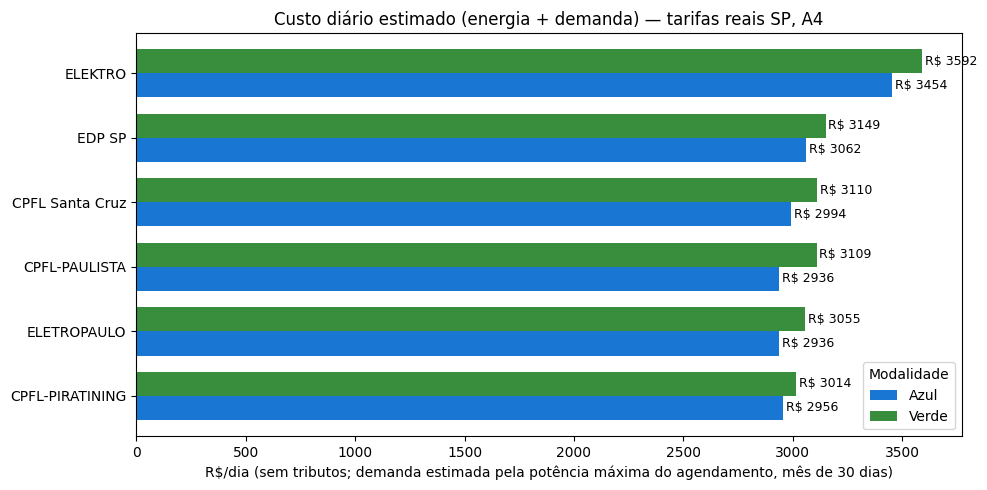

In [6]:
import matplotlib.pyplot as plt

def resolver_cenario(modelo, c_fora, c_ponta, horas_ponta=HORAS_PONTA):
    """Re-resolve uma cópia do modelo com novas tarifas (só muda a função objetivo)."""
    mc = modelo.copy()
    mc.setParam("OutputFlag", 0)
    mc.update()
    Ct = {t: (c_ponta if t in horas_ponta else c_fora) for t in horas}
    for p in bombas:
        for t in horas:
            mc.getVarByName(f"x[{p},{t}]").Obj = Ct[t] * param_bombas[p][0]
    mc.optimize()
    if mc.SolCount == 0:
        return None
    kwh = {t: sum(param_bombas[p][0] * mc.getVarByName(f"x[{p},{t}]").X for p in bombas) for t in horas}
    kwh_total = sum(kwh.values())
    kwh_ponta = sum(kwh[t] for t in horas_ponta)
    # Potência (kW) = energia de 1 hora; demanda medida = maior potência em cada período
    dem_ponta = max(kwh[t] for t in horas_ponta)
    dem_fora = max(kwh[t] for t in horas if t not in horas_ponta)
    return {"Custo (R$/dia)": mc.ObjVal, "Energia (kWh/dia)": kwh_total,
            "Energia na ponta (kWh)": kwh_ponta, "Custo médio (R$/kWh)": mc.ObjVal / kwh_total,
            "Dem. ponta (kW)": dem_ponta, "Dem. fora ponta (kW)": dem_fora, "Dem. máx (kW)": max(dem_ponta, dem_fora)}

linhas = [{"Cenário": "Hipotético original", "Distribuidora": "-", "Modalidade": "-",
           "Fora ponta (R$/kWh)": 0.60, "Ponta (R$/kWh)": 2.80, "Demanda est. (R$/dia)": np.nan, **resolver_cenario(m, 0.60, 2.80)}]
for dist in DISTRIBUIDORAS_SP:
    for mod in ["Verde", "Azul"]:
        tt = tarifa_kwh(aneel, dist, mod, "A4")
        td = tarifa_demanda_kw(aneel, dist, mod, "A4")
        res = resolver_cenario(m, tt["fora_ponta"], tt["ponta"])
        if mod == "Azul":
            dem_mes = td["ponta"] * res["Dem. ponta (kW)"] + td["fora_ponta"] * res["Dem. fora ponta (kW)"]
        else:
            dem_mes = td["unica"] * res["Dem. máx (kW)"]
        linhas.append({"Cenário": f"{dist} {mod}", "Distribuidora": dist, "Modalidade": mod,
                       "Fora ponta (R$/kWh)": tt["fora_ponta"], "Ponta (R$/kWh)": tt["ponta"],
                       "Demanda est. (R$/dia)": dem_mes / 30, **(res or {})})

cenarios = pd.DataFrame(linhas)
cenarios["Ponta/Fora ponta (x)"] = cenarios["Ponta (R$/kWh)"] / cenarios["Fora ponta (R$/kWh)"]
cenarios["Total est. (R$/dia)"] = cenarios["Custo (R$/dia)"] + cenarios["Demanda est. (R$/dia)"]
cols = ["Cenário", "Fora ponta (R$/kWh)", "Ponta (R$/kWh)", "Ponta/Fora ponta (x)",
        "Custo (R$/dia)", "Energia (kWh/dia)", "Energia na ponta (kWh)", "Custo médio (R$/kWh)",
        "Demanda est. (R$/dia)", "Total est. (R$/dia)"]
fmt_cen = {"Fora ponta (R$/kWh)": "{:.4f}", "Ponta (R$/kWh)": "{:.4f}", "Ponta/Fora ponta (x)": "{:.2f}",
           "Custo (R$/dia)": "{:,.2f}", "Energia (kWh/dia)": "{:,.1f}",
           "Energia na ponta (kWh)": "{:,.1f}", "Custo médio (R$/kWh)": "{:.4f}",
           "Demanda est. (R$/dia)": "{:,.2f}", "Total est. (R$/dia)": "{:,.2f}"}
try:
    display(cenarios[cols].style.format(fmt_cen, na_rep="—").hide(axis="index"))
except AttributeError:   # sem jinja2: mostra a tabela sem formatação (ou: pip install jinja2)
    display(cenarios[cols].round(4))

sp_cen = cenarios[cenarios["Distribuidora"] != "-"].copy()
pv = sp_cen.pivot(index="Distribuidora", columns="Modalidade", values="Total est. (R$/dia)").sort_values("Verde")
ax = pv.plot(kind="barh", figsize=(10, 5), width=0.75, color=["#1976D2", "#388E3C"])
for cont in ax.containers:
    ax.bar_label(cont, fmt="R$ %.0f", padding=2, fontsize=9)
ax.set_title("Custo diário estimado (energia + demanda) — tarifas reais SP, A4")
ax.set_xlabel("R$/dia (sem tributos; demanda estimada pela potência máxima do agendamento, mês de 30 dias)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

### Leitura dos resultados (cenário: demanda de verão da célula de parâmetros)

- **Tarifas reais x hipotéticas:** com as tarifas da ANEEL, o custo de energia cai de **R$ 4.208/dia** (R$ 0,60 / R$ 2,80) para algo entre **R$ 2.231 e R$ 3.365/dia**, porque a ponta real em SP (R$ 0,53 a R$ 2,20/kWh) é bem menor que os R$ 2,80 hipotéticos.
- **O bombeamento na ponta não pode ser zerado neste cenário.** Mesmo nas tarifas Verde (ponta 3x a 5,6x o fora ponta), o modelo mantém **410 kWh na ponta**. Isso não é falha de otimização: o teste de forçar as bombas desligadas às 17h, 18h e 19h torna o modelo **inviável**, pois a demanda dessas 3 horas (~3.097 m³) é maior que o volume útil dos 5 reservatórios (~2.550 m³). Para tirar a ponta do bombeamento, seria preciso mais armazenamento ou uma curva de demanda menos concentrada.
- **Verde x Azul:** só no custo de energia a Azul parece bem mais barata, mas isso engana: a Azul cobra a demanda à parte. Somando a **estimativa de demanda**, o total fica **2% a 6% menor na Azul** em todas as distribuidoras testadas. A diferença é pequena e depende da estimativa de demanda (o modelo não otimiza demanda) e do `MIPGap` de 1%, então trate como indicativo.
- **Distribuidora:** a Elektro tem o maior custo total e a CPFL Piratininga/Paulista e a Enel SP os menores na Azul. As diferenças vêm principalmente do fora ponta (R$ 0,395 a R$ 0,483/kWh), que concentra a maior parte da energia.

### Limitações
- Tarifas **sem tributos e sem bandeiras**; o CSV não traz os **horários de ponta** (usa-se 17h-19h como no modelo, mas cada distribuidora define o seu).
- Escolhemos o subgrupo **A4**; a ETA pode estar em outro subgrupo (A3a, A2, AS).
- A demanda estimada é a potência máxima das bombas ligadas no período, **não** a demanda contratada real.